# **Spin-Informed Equivariant Graph Neural Networks (SI-EGNNs)**

## 1. **Overview**
  This notebook implements a model designed to predict the decoherence time of $NV^{0}$ centers in diamond. The model is built to respect E(3) equivariance (rotations, reflections and translations), ensuring that the physical properties of the spin bath are preserved across different coordinate systems.

## 2. **Dataset**
  The model is trained on an artificial dataset generated using the pyCCE package. There are around 1200 total samples: 15 different random geometries paired with 40 Gaussian spin bath polarizations, and vice versa. Spin polarization is expressed through its density matrix:
  $$\rho = \begin{pmatrix} \rho_{00} & \rho_{01} \\ \rho_{10} & \rho_{11} \end{pmatrix}$$

## 3. **Requirements and environment setup**
  The model was implemented using PyTorch Geometric within the Google Colab ecosystem. To ensure computational efficiency, GPU acceleration is highly recommended during the training phase.

In [37]:
!pip install torch_geometric torch_scatter -f https://data.pyg.org/whl/torch-{torch.__version__}.html

Looking in links: https://data.pyg.org/whl/torch-2.10.0+cu128.html


In [38]:
import torch
import torch.optim as optim
import os
import matplotlib.pyplot as plt
import pandas as pd
import ast
import numpy as np
import time
import torch_geometric
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch import nn
from torch.utils.data import TensorDataset
from torch.utils.data import random_split
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch_scatter import scatter_sum, scatter_mean
from google.colab import drive

In [ ]:
drive.mount('/content/drive', force_remount=True)
# path = insert your path
dataset = pd.read_pickle(path)

Mounted at /content/drive


### **1. Definition of the hyperparameter of the model**

In [40]:
train_partition = 0.8
val_partition = 0.1
batch_size_param = 8
n_layers_param = 2
message_dim_param = 8
max_norm_param = 1
lr_param = 1e-4

LR_reduction_factor = 0.5
LR_reduction_patience = 3
LR_reduction_threshold = 0.005

n_epochs = 30

# Early stopping parameters
early_stopping_patience = 20 # Number of epochs to wait for improvement
min_delta = 1.e-5 # Minimum change in validation loss to be considered an improvement

### **2. Data loading and preprocessing**

In [41]:
T2_list = []
coors_list = []
bloch_vector_list = []
features_list = []

for i in range(len(dataset['t2_list'])):

    diamond_coors = []
    diamond_bloch_vector = []
    diamond_features = []

    for atom_data in dataset['coors_rho_Z_list'][i]:
        # atom_data is: [x, y, z, rho00, rho01, rho10, rho11, scalar_feature]
        # scalar_feature = 0 for NV0 centers, = 1 for 13C

        diamond_coors.append(atom_data[0:3])

        # Conversion from density matrix to Bloch Vector
        rho00, rho01, rho10, rho11 = atom_data[3:7]
        rx = 2 * rho01
        ry = 0.0 # Since all density matrix are real
        rz = rho00 - rho11
        if abs(rz) < 1e-6:
            rz = 0.0
        diamond_bloch_vector.append([rx, ry, rz])

        diamond_features.append([atom_data[7]])

    # Decoherence time (target quantity)
    T2_list.append(dataset['t2_list'][i])

    # Converts lists of inputs into PyTorch tensors and appends them to their respective global lists
    coors_list.append(torch.tensor(np.array(diamond_coors), dtype = torch.float32))
    bloch_vector_list.append(torch.tensor(np.array(diamond_bloch_vector), dtype = torch.float32))
    features_list.append(torch.tensor(np.array(diamond_features), dtype = torch.float32))

T2_tensor = torch.tensor(T2_list, dtype=torch.float32).unsqueeze(-1) # An additional dimension is added for future operations

# Class DATA: represents a single diamond lattice
class CustomGraphData(Data):
    def __init__(self, h=None, edge_index=None, coors=None, bloch_vector=None, t2=None, nv_idx=None, **kwargs):
        super().__init__(h=h, edge_index=edge_index, coors=coors, t2=t2, **kwargs)
        self.bloch_vector = bloch_vector
        self.nv_idx = nv_idx # Local index of the NV center in this graph

    def __inc__(self, key, value, *args, **kwargs):
        """
        Defines how attributes should be incremented when merging multiple
        graphs into a single Batch object.
        """
        # Edge indices must be incremented by the number of nodes in the previous
        # graphs in the batch to maintain correct global indexing.
        if key == 'edge_index':
            return self.h.size(0)
        if key == 'nv_idx':
            return 0 # nv_idx is a local index *within* each graph, so no increment needed
        return super().__inc__(key, value, *args, **kwargs)


class CustomGraphDataset(Dataset):
    """
    Dataset class for NV0 center spin environments in diamond lattices.

    Each sample represents a diamond lattice as a fully connected graph, where nodes
    are 13C isotopes and the final node corresponds to the NV0 center.
    """
    def __init__(self, features_list, coors_list, bloch_vector_list, t2_targets):
        super().__init__()
        self.features_list = features_list
        self.coors_list = coors_list
        self.bloch_vector_list = bloch_vector_list
        self.t2_targets = t2_targets
        self.num_graphs = len(features_list)

    def len(self):
        """Returns the total number of graph samples in the dataset."""
        return self.num_graphs

    def get(self, idx):
        """
        Constructs a single graph data object from precomputed lists.

        Args:
            idx (int): Index of the sample to retrieve.

        Returns:
            CustomGraphData: PyG Data object containing node features, coordinates,
                             Bloch vectors, and the target T2 (decoherence) time.
        """
        # Node features (h): [num_nodes, features_dim]
        h = self.features_list[idx]
        # Spatial coordinates (coors): [num_nodes, 3]
        coors = self.coors_list[idx]
        # Spin states (bloch_vector): [num_nodes, 3]
        bloch_vector = self.bloch_vector_list[idx]
        # Regression target (T2): scalar
        t2 = self.t2_targets[idx]

        # Identify the NV center: by convention, it is the last node in the list
        nv_idx = h.size(0) - 1

        # Generate a fully connected adjacency matrix (excluding self-loops)
        # This allows the GNN to model all-to-all spin interactions
        num_nodes = h.size(0)

        # Optimized edge_index generation:
        # Create a boolean mask for all possible edges
        adj_matrix = torch.ones(num_nodes, num_nodes, dtype=torch.bool)

        # Convert the adjacency matrix to COO format: [2, num_edges]
        edge_index = adj_matrix.nonzero(as_tuple=False).t().contiguous()

        return CustomGraphData(
            h=h,
            edge_index=edge_index,
            coors=coors,
            bloch_vector=bloch_vector,
            t2=t2,
            nv_idx=nv_idx
        )

# Initialize Global Dataset (Unnormalized)
full_graph_dataset = CustomGraphDataset(features_list, coors_list, bloch_vector_list, T2_tensor)

# Partitioning: Train/Val/Test Split
total_size = len(full_graph_dataset)
train_size = int(train_partition * total_size)
val_size = int(val_partition * total_size)
test_size = total_size - train_size - val_size

# Use random_split for initial subset generation
train_data_unnorm, val_data_unnorm, test_data_unnorm = torch.utils.data.random_split(
    full_graph_dataset, [train_size, val_size, test_size]
)

all_train_coors = torch.cat([data.coors for data in train_data_unnorm])
all_train_t2 = torch.cat([data.t2 for data in train_data_unnorm])

# Mean and Std are computed only from the unnormalized training partition to prevent data leakage.
coors_train_mean, coors_train_std = all_train_coors.mean(), all_train_coors.std()
T2_train_mean, T2_train_std = all_train_t2.mean(), all_train_t2.std()

# Feature scaling (Z-score Normalization)
# We apply training-derived statistics to the entire set. This creates new lists with normalized values
normalized_coors_list = [(c - coors_train_mean) / (coors_train_std + 1e-8) for c in coors_list]
normalized_T2_tensor = (T2_tensor - T2_train_mean) / (T2_train_std + 1e-8)

# Dataset Re-instantiation using normalized lists
full_graph_dataset = CustomGraphDataset(features_list, normalized_coors_list, bloch_vector_list, normalized_T2_tensor)

# Final subset generation using indices from the initial splitting
# Map original indices to the normalized dataset to maintain split consistency.
train_data = torch.utils.data.Subset(full_graph_dataset, train_data_unnorm.indices)
val_data = torch.utils.data.Subset(full_graph_dataset, val_data_unnorm.indices)
test_data = torch.utils.data.Subset(full_graph_dataset, test_data_unnorm.indices)

# PyG DataLoader Configuration
train_loader = DataLoader(train_data, batch_size=batch_size_param, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_data, batch_size=batch_size_param, shuffle=False, pin_memory=True)
test_loader = DataLoader(test_data, batch_size=batch_size_param, shuffle=False, pin_memory=True)


print(f"PyG Dataset split into:")
print(f"  Training: {len(train_data)} samples")
print(f"  Validation: {len(val_data)} samples")
print(f"  Test: {len(test_data)} samples")

PyG Dataset split into:
  Training: 862 samples
  Validation: 107 samples
  Test: 109 samples


### **3. Model definition**

In [42]:
class MyCustomEGNNLayer(nn.Module):
    """
    SI-Equivariant Graph Neural Network (SI-EGNN) Layer.

    This layer updates:
    1. Node Features
    2. Coordinates
    3. Bloch Vectors
    """
    def __init__(self, features_dim, message_dim):
        super().__init__()

       # 1. MLP for the message update (phi_e)
        # Input: h_i, h_j, ||x_i - x_j||^2, ||rho_i - rho_j||^2, edge_attr (optional)
        self.edge_mlp = nn.Sequential(
            nn.Linear(features_dim * 2 + 1 + 1, message_dim),
            nn.LayerNorm(message_dim),
            nn.ReLU(),
            nn.Linear(message_dim, message_dim),
            nn.ReLU(),
            nn.Linear(message_dim, message_dim)
        )

        # 2. MLP for coordinates update (phi_x)
        self.coors_mlp = nn.Sequential(
            nn.Linear(message_dim, message_dim),
            nn.LayerNorm(message_dim),
            nn.SiLU(),
            nn.Linear(message_dim, message_dim),
            nn.SiLU(),
            nn.Linear(message_dim, 1)
        )

        # 3. MLP for features update (phi_h)
        self.features_mlp = nn.Sequential(
            nn.Linear(features_dim + message_dim, message_dim),
            nn.ReLU(),
            nn.Linear(message_dim, message_dim),
            nn.ReLU(),
            nn.Linear(message_dim, features_dim)
        )

        # 4. MLP for Bloch vectors update (phi_bv)
        self.bloch_vector_mlp = nn.Sequential(
            nn.Linear(message_dim, message_dim),
            nn.SiLU(),
            nn.Linear(message_dim, message_dim),
            nn.SiLU(),
            nn.Linear(message_dim, 1)
        )

    def forward(self, h, coors, bloch_vector, edge_index, batch):
        """
        Forward pass for the Equivariant Layer (L -> L+1).

        Args:
            h (Tensor): Node features [TotalNodesInBatch, features_dim]
            coors (Tensor): Node coordinates [TotalNodesInBatch, 3]
            bloch_vector (Tensor): Node Bloch vectors [TotalNodesInBatch, 3]
            edge_index (Tensor): Graph connectivity [2, NumEdgesInBatch]
            batch (Tensor): Graph membership mapping [TotalNodesInBatch,]

        Returns:
            h_out (Tensor): Updated node features [TotalNodesInBatch, features_dim]
            coors_out (Tensor): Updated equivariant coordinates [TotalNodesInBatch, 3]
            bloch_vector_out (Tensor): Updated equivariant spin vectors [TotalNodesInBatch, 3]
        """
        row, col = edge_index # row = source node indices, col = target node indices

        # Prepare inputs for edge_mlp
        h_i, h_j = h[row], h[col]
        coors_i, coors_j = coors[row], coors[col]
        bloch_vector_i, bloch_vector_j = bloch_vector[row], bloch_vector[col]

        # ||x_i - x_j||^2
        coors_dist_ij = coors_i - coors_j
        rel_coors_norm_sq = (coors_dist_ij * coors_dist_ij).sum(dim=-1, keepdim=True)

        # ||r_i - r_j||^2
        bloch_dist_ij = bloch_vector_i - bloch_vector_j
        rel_bloch_norm_sq = (bloch_dist_ij * bloch_dist_ij).sum(dim=-1, keepdim=True)

        message_input = torch.cat([h_i, h_j, rel_coors_norm_sq, rel_bloch_norm_sq], dim=-1)

        # Message passing
        m_ij = self.edge_mlp(message_input)

        # Equivariant coordinate update
        coors_weights = self.coors_mlp(m_ij)
        coors_updated = coors_dist_ij * coors_weights # (TotalEdgesInBatch, 3)
        delta_coors = scatter_mean(coors_updated, col, dim=0, dim_size=h.size(0))
        coors_out = coors + delta_coors

        # Equivariant Bloch vector update
        bloch_vector_weights = self.bloch_vector_mlp(m_ij)
        bloch_vector_updated = bloch_dist_ij * bloch_vector_weights # (TotalEdgesInBatch, 3)
        delta_bloch_vector = scatter_mean(bloch_vector_updated, col, dim=0, dim_size=h.size(0))
        bloch_vector_out = bloch_vector + delta_bloch_vector

        # Aggregate messages for node feature update
        m_i = scatter_sum(m_ij, col, dim=0, dim_size=h.size(0)) # Sum messages for each target node (col)

        # Update node features
        h_out = self.features_mlp(torch.cat([h, m_i], dim=-1))

        return h_out, coors_out, bloch_vector_out

class EgnnLayers(nn.Module):
    """
    Modular container for stacking multiple Equivariant Graph Neural Network layers.

    This class manages the recursive update of node features, coordinates, and
    Bloch vectors across a specified number of message-passing steps.
    """
    def __init__(self, n_layers=4, features_dim=1, message_dim=128):
        """
        Args:
            n_layers (int): Total number of equivariant blocks to stack.
            features_dim (int): Dimensionality of the node hidden states.
            message_dim (int): Dimensionally of the latent messages (m_ij).
        """
        super().__init__()

        self.layers = nn.ModuleList([
            MyCustomEGNNLayer(features_dim=features_dim, message_dim=message_dim)
            for _ in range(n_layers)
        ])

    def forward(self, h, coors, bloch_vector, edge_index, batch):
        """
        Iterative forward pass through the stack of equivariant layers.

        Each layer takes the output of the previous layer as its input,
        progressively updating the features and equivariant coordinates
        and Bloch vectors.

        Args:
            h (Tensor): Initial node features [TotalNodesInBatch, features_dim]
            coors (Tensor): Initial node coordinates [TotalNodesInBatch, 3]
            bloch_vector (Tensor): Initial Bloch vectors [TotalNodesInBatch, 3]
            edge_index (Tensor): Connectivity matrix [2, NumEdgesInBatch]
            batch (Tensor): Graph membership vector [TotalNodesInBatch,]

        Returns:
            h (Tensor): Final latent node features.
            coors (Tensor): Final updated coordinates.
            bloch_vector (Tensor): Final updated Bloch vectors.
        """

        # We iterate through the layer stack, overwriting the tensors at each step.
        for layer in self.layers:
            h, coors, bloch_vector = layer(h, coors, bloch_vector, edge_index, batch)

        return h, coors, bloch_vector


class T2Readout(nn.Module):
    """
    Readout module to extract NV center features and perform graph-level regression.
    """
    def __init__(self, features_dim=1):
        super().__init__()
        # Final Regressor: Concatenates NV hidden features and its Bloch vector
        # Input size: features_dim + 3 (Bloch vector)
        self.mlp = nn.Sequential(
            nn.Linear(features_dim + 3, message_dim_param),
            nn.Linear(message_dim_param, 1),
        )

    def forward(self, h, bloch_vector, batch, nv_idx_per_graph_local):
        """
        Args:
            h (Tensor): Node features from the last EGNN layer [TotalNodesInBatch, features_dim]
            bloch_vector (Tensor): Updated Bloch vectors [TotalNodesInBatch, 3]
            batch (Tensor): map nodes to their graph in the batch [TotalNodesInBatch,]
            nv_idx_per_graph_local (Tensor): contains local NV index for each graph [NumGraphsInBatch,]

        Returns:
            predicted_t2 (Tensor): Predicted standardized T2 values [NumGraphsInBatch, 1]
        """

        # Determine the total number of independent graphs in the current batch
        num_graphs_in_batch = batch.max().item() + 1

        # Map local NV indices to global batch indices
        # This loop identifies the absolute position of each NV center within the flattened batch
        global_nv_indices = []
        for i in range(num_graphs_in_batch):
            # Find all node indices belonging to graph 'i'
            nodes_in_graph_i = (batch == i).nonzero(as_tuple=True)[0]

            if len(nodes_in_graph_i) > 0:
                # Retrieve the local NV index for graph 'i'
                local_nv_idx = nv_idx_per_graph_local[i].item()

                # Append the global index of NV center (global index of first node + local NV index)
                global_nv_indices.append(nodes_in_graph_i[local_nv_idx])

        global_nv_indices = torch.tensor(global_nv_indices, device=h.device)

        # Extract specifically the features and Bloch vectors for the target NV centers
        nv_features = h[global_nv_indices]      # Shape: (num_graphs_in_batch, features_dim)
        nv_bloch = bloch_vector[global_nv_indices] # Shape: (num_graphs_in_batch, 3)

        # Concatenate and pass through the MLP to output the final prediction
        h_concat = torch.cat([nv_features, nv_bloch], dim=-1)
        predicted_t2 = self.mlp(h_concat)

        return predicted_t2

class NeuralNetwork(nn.Module):
    """
    This class integrates the multi-layer equivariant processing blocks with
    the targeted readout layer to predict the decoherence time.
    """
    def __init__(self, n_layers=n_layers_param, features_dim=1, message_dim=message_dim_param):
        super().__init__()
        self.egnn_layers = EgnnLayers(n_layers, features_dim, message_dim)
        self.T2_readout = T2Readout(features_dim)

    def forward(self, data):
        """
        Args:
            data (torch_geometric.data.Batch): A batch object containing node features,
                                               coordinates, Bloch vectors, and connectivity.

        Returns:
            predicted_t2 (Tensor): Regression output for each graph in the batch [NumGraphsInBtach, 1].
        """
        h, coors, bloch_vector, edge_index, batch, t2_target, nv_idx_per_graph_local = \
            data.h, data.coors, data.bloch_vector, data.edge_index, data.batch, data.t2, data.nv_idx

        h, coors, bloch_vector = self.egnn_layers(h, coors, bloch_vector, edge_index, batch)

        predicted_t2 = self.T2_readout(h, bloch_vector, batch, nv_idx_per_graph_local)

        return predicted_t2

### **4. Training loop**

In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model initialization
model = NeuralNetwork(n_layers=n_layers_param, features_dim=1, message_dim=message_dim_param)
model.to(device)

# Backpropagation algorithm: ADAM
optimizer = optim.Adam(model.parameters(), lr=lr_param)

# Loss function: MSE
criterion = nn.MSELoss()

# Automatically reduce the learning rate when the model's performance on a validation metric stops improving
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=LR_reduction_factor,
    patience=LR_reduction_patience,
    threshold=LR_reduction_threshold
)

def train_step(data):
    """
    Args:
        data (torch_geometric.data.Batch): A batch object containing node features,
                                           coordinates, Bloch vectors, and connectivity.
    Returns:
        loss (float): The scalar loss value for the current batch
    """
    model.train()
    optimizer.zero_grad()

    data = data.to(device)

    predicted_t2 = model(data)

    loss = criterion(predicted_t2.squeeze(), data.t2.squeeze())

    loss.backward()

    # Add gradient clipping (to prevent gradient value from exploding)
    nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_norm_param)

    optimizer.step()

    return loss.item()

train_losses = []
val_losses = []

best_val_loss = float('inf') # Tracks the lowest loss obtained so far in the epochs
epochs_no_improve = 0
current_lr = lr_param

start_time = time.time() # Record the start time of the training

best_model_path = 'best_model.pt' # Save weights corresponding to best val_loss

# Training and validation cicles
for epoch in range(n_epochs):
    model.train() # Set everything to training mode
    total_train_loss = 0 # Initialize total loss to 0

    for batch_data in train_loader:

        train_loss = train_step(batch_data)
        total_train_loss += train_loss

    # Validation phase
    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for batch_data_val in val_loader:
            # Move validation batch data to the same device as the model
            batch_data_val = batch_data_val.to(device)
            # Prediction
            pred = model(batch_data_val)
            # Validation Loss calculation (using the same criterion as training)
            v_loss = criterion(pred.squeeze(), batch_data_val.t2.squeeze())

            total_val_loss += v_loss.item()

    avg_train = total_train_loss / len(train_loader)
    avg_val = total_val_loss / len(val_loader)

    # Store the losses
    train_losses.append(avg_train)
    val_losses.append(avg_val)

    elapsed_time = time.time() - start_time
    print(f"Epoca {epoch+1}: Train Loss = {avg_train:.6f} | Val Loss = {avg_val:.4f} | LR = {current_lr:.1e} | epochs no improve = {epochs_no_improve} | Runtime = {elapsed_time:.2f}s")


    scheduler.step(avg_val)
    current_lr = optimizer.param_groups[0]['lr']


    # Early stopping
    if avg_val < best_val_loss - min_delta:
        best_val_loss = avg_val
        epochs_no_improve = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        epochs_no_improve += 1

    if epochs_no_improve == early_stopping_patience:
        print(f"Early Stopping: Validation loss has not improved for {early_stopping_patience} epochs. Stopping training.")
        break

model.load_state_dict(torch.load(best_model_path))

/usr/local/lib/python3.12/dist-packages/torch_geometric/data/collate.py:142: UserWarning: Unable to accurately infer 'num_nodes' from the attribute set '{'edge_index', 'nv_idx', 'coors', 'bloch_vector', 'h', 't2'}'. Please explicitly set 'num_nodes' as an attribute of 'data' to suppress this warning
  repeats = [store.num_nodes or 0 for store in stores]


Epoca 1: Train Loss = 0.984628 | Val Loss = 0.9347 | LR = 1.0e-04 | epochs no improve = 0 | Runtime = 17.21s
Epoca 2: Train Loss = 0.776243 | Val Loss = 0.6702 | LR = 1.0e-04 | epochs no improve = 0 | Runtime = 34.38s
Epoca 3: Train Loss = 0.568755 | Val Loss = 0.4642 | LR = 1.0e-04 | epochs no improve = 0 | Runtime = 51.72s
Epoca 4: Train Loss = 0.440636 | Val Loss = 0.3653 | LR = 1.0e-04 | epochs no improve = 0 | Runtime = 68.91s
Epoca 5: Train Loss = 0.394403 | Val Loss = 0.3466 | LR = 1.0e-04 | epochs no improve = 0 | Runtime = 86.32s
Epoca 6: Train Loss = 0.362341 | Val Loss = 0.3244 | LR = 1.0e-04 | epochs no improve = 0 | Runtime = 103.55s
Epoca 7: Train Loss = 0.342965 | Val Loss = 0.3036 | LR = 1.0e-04 | epochs no improve = 0 | Runtime = 120.91s
Epoca 8: Train Loss = 0.324882 | Val Loss = 0.3353 | LR = 1.0e-04 | epochs no improve = 0 | Runtime = 138.36s
Epoca 9: Train Loss = 0.325572 | Val Loss = 0.2945 | LR = 1.0e-04 | epochs no improve = 1 | Runtime = 155.70s
Epoca 10: Train

<All keys matched successfully>

### **5. Results and testing**

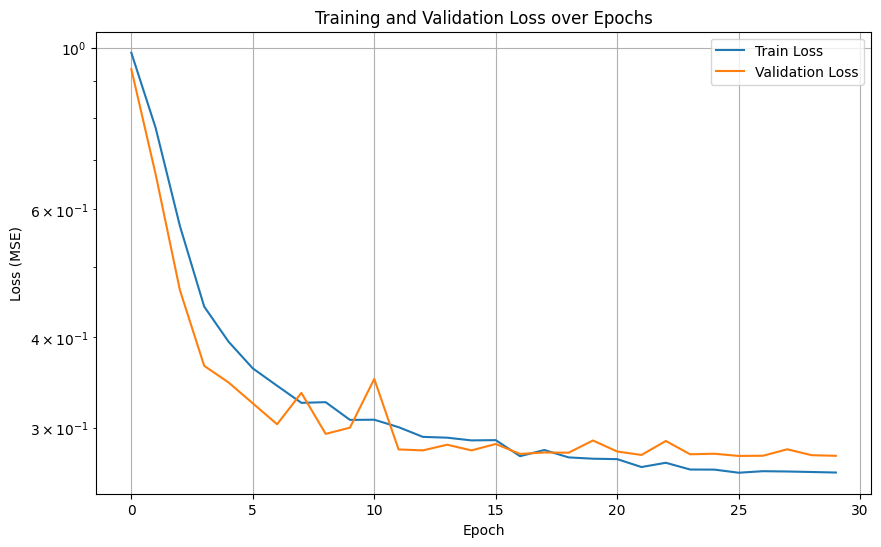

Test Set Evaluation 
MAE (Normalized):      0.3847 (Standard Deviation)
MAE (Denormalized):    0.1768
Mean Relative Error:   20.7709 %
R-squared (R2) Score:  0.7783


In [46]:
# Losses plot
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.yscale('log')
plt.show()

# Test phase
model.eval()

all_predicted_t2_norm = []
all_actual_t2_norm = []
all_predicted_t2 = []
all_actual_t2 = []

with torch.no_grad():
    for batch_data_test in test_loader:
        batch_data_test = batch_data_test.to(device)

        # Predict normalized T2 using the model
        predicted_t2_norm = model(batch_data_test)

        # Store normalized values
        all_predicted_t2_norm.extend(predicted_t2_norm.flatten().tolist())
        all_actual_t2_norm.extend(batch_data_test.t2.flatten().tolist())

        # Denormalize the predicted T2 values using parameters from the TRAINING set
        predicted_t2_denorm = (predicted_t2_norm.squeeze() * T2_train_std) + T2_train_mean
        actual_t2_denorm = (batch_data_test.t2.squeeze() * T2_train_std) + T2_train_mean

        all_predicted_t2.extend(predicted_t2_denorm.flatten().tolist())
        all_actual_t2.extend(actual_t2_denorm.flatten().tolist())

all_predicted_t2 = np.array(all_predicted_t2)
all_actual_t2 = np.array(all_actual_t2)
all_predicted_t2_norm = np.array(all_predicted_t2_norm)
all_actual_t2_norm = np.array(all_actual_t2_norm)

# Metrics for model evaluation:
# 1. MAE Denormalized
mae_denorm = np.mean(np.abs(all_actual_t2 - all_predicted_t2))

# 2. MAE Normalized (Scale-free)
mae_norm = np.mean(np.abs(all_actual_t2_norm - all_predicted_t2_norm))

# 3. Mean Relative Error (MRE)
# Use absolute value in the denominator for safety
mre = np.mean(np.abs((all_actual_t2 - all_predicted_t2) / all_actual_t2)) * 100

# 4. R-squared (R2) Score
ss_total = np.sum((all_actual_t2 - np.mean(all_actual_t2)) ** 2)
ss_residual = np.sum((all_actual_t2 - all_predicted_t2) ** 2)
r2 = 1 - (ss_residual / ss_total) if ss_total > 0 else 0.0

print(f"Test Set Evaluation ")
print(f"MAE (Normalized):      {mae_norm:.4f} (Standard Deviation)")
print(f"MAE (Denormalized):    {mae_denorm:.4f}")
print(f"Mean Relative Error:   {mre:.4f} %")
print(f"R-squared (R2) Score:  {r2:.4f}")